## 📊 Bank Marketing Campaign
This notebook presents an exploratory and predictive analysis of the **Bank Marketing Dataset**.  
The dataset contains information about customers contacted during a marketing campaign and records whether they subscribed to a term deposit (`deposit = 1`) or not (`deposit = 0`).

The analysis is reported in a structured way:
- The dataset is described.  
- Exploratory data analysis (EDA) is conducted with visuals.  
- A baseline logistic regression model is trained and evaluated.  
- Key insights are reported.


## 2. Data Loading and Overview


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv("../input/bank-marketing-dataset/bank.csv")
df.info()

# Convert yes/no to 1/0
df['deposit'] = df['deposit'].str.lower().map({'yes': 1, 'no': 0})

print("Response rate:", df['deposit'].mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB
Response rate: 0.4738398136534671


## 3. Class Balance
The distribution of the target variable (`deposit`) is examined.  
It is observed that only a minority of customers subscribed, indicating a class imbalance.


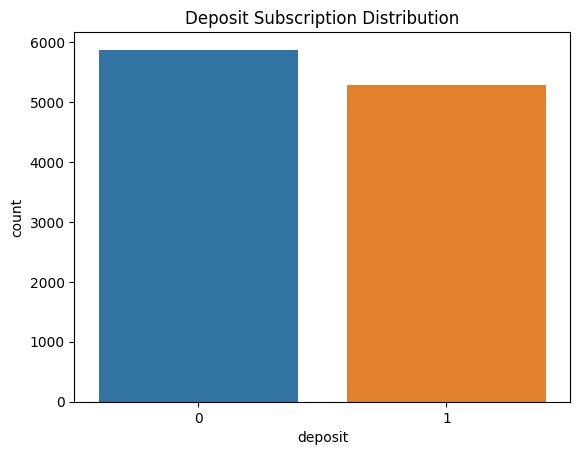

In [2]:
sns.countplot(x='deposit', data=df)
plt.title("Deposit Subscription Distribution")
plt.show()

## 4. Response Rate by Category
The average response rate is computed across key categorical features.  
This helps identify which customer groups were more likely to subscribe.

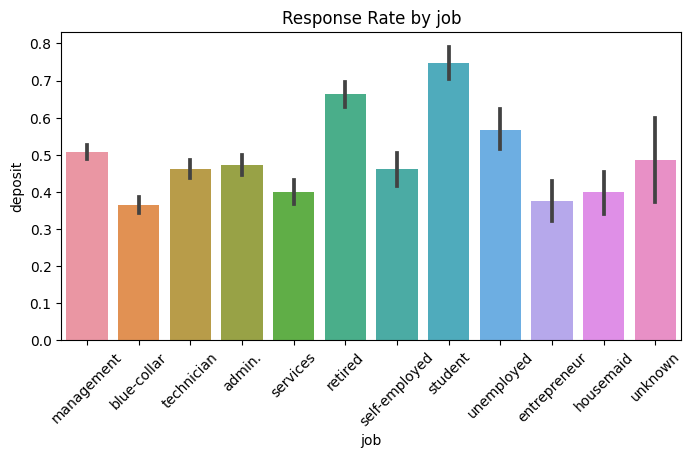

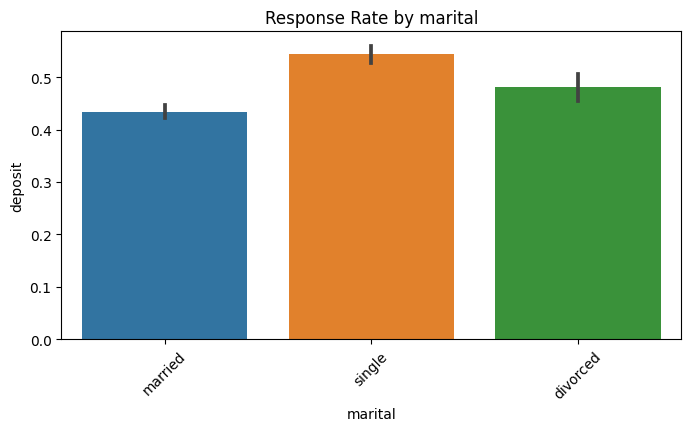

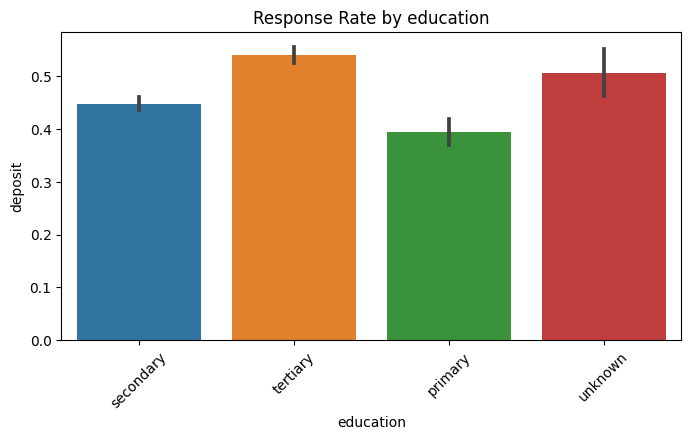

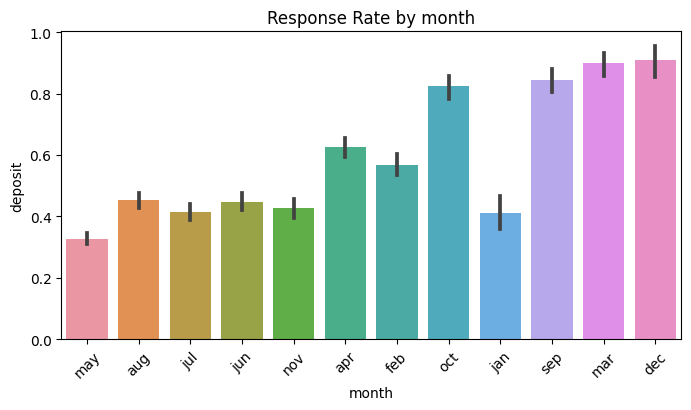

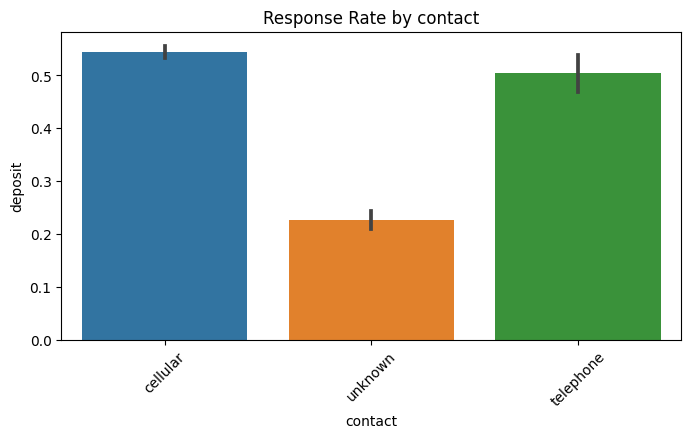

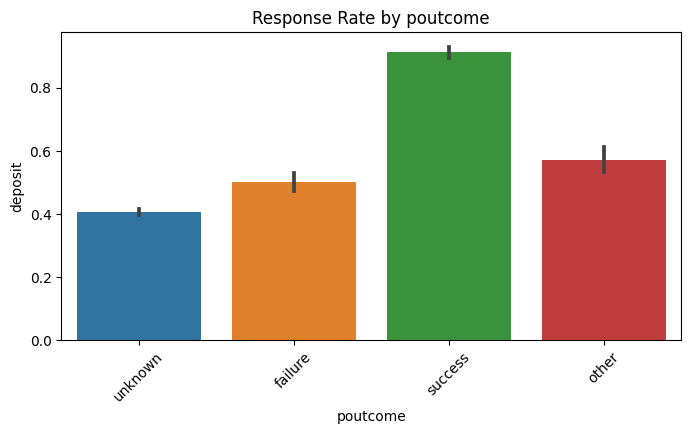

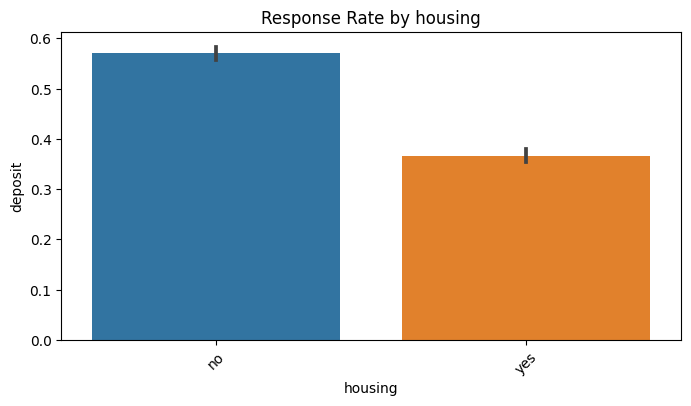

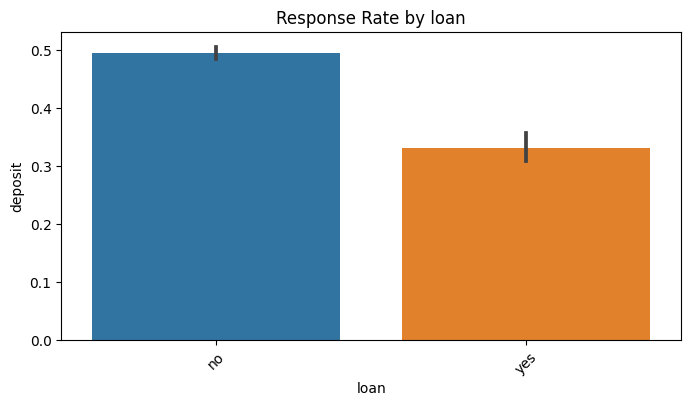

In [3]:
for col in ['job','marital','education','month','contact','poutcome','housing','loan']:
    plt.figure(figsize=(8,4))
    sns.barplot(x=col, y='deposit', data=df, estimator=np.mean, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Response Rate by {col}")
    plt.show()

### Analysis:
The barplots revealed that subscription rates varied across different customer groups:

* **Job**: Students and retired individuals had noticeably higher subscription rates, while blue-collar workers showed lower rates.

* **Education**: Higher education levels correlated with greater likelihood of subscription.

* **Month**: Certain months, such as March and September, showed spikes in responses, suggesting that campaign timing influenced outcomes.

* **Contact Method**: Customers contacted via cellular methods were more likely to subscribe compared to those reached through traditional telephone.

* **Poutcome (previous campaign outcome)**: Customers with a successful outcome in prior campaigns were more likely to respond positively again.

These findings highlight which groups were most receptive, offering potential guidance for future targeted campaigns.

## 5. Numeric Feature Distributions
  
For each feature, a histogram was drawn with a smooth density curve (KDE).  
Additionally, the mean value of each feature was highlighted with a red dashed line and annotated on the plot.  

This analysis revealed that some features, such as **duration** and **balance**, are highly skewed, while others such as **age** follow a more bell-shaped distribution.  
These characteristics provide context before applying predictive modeling.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

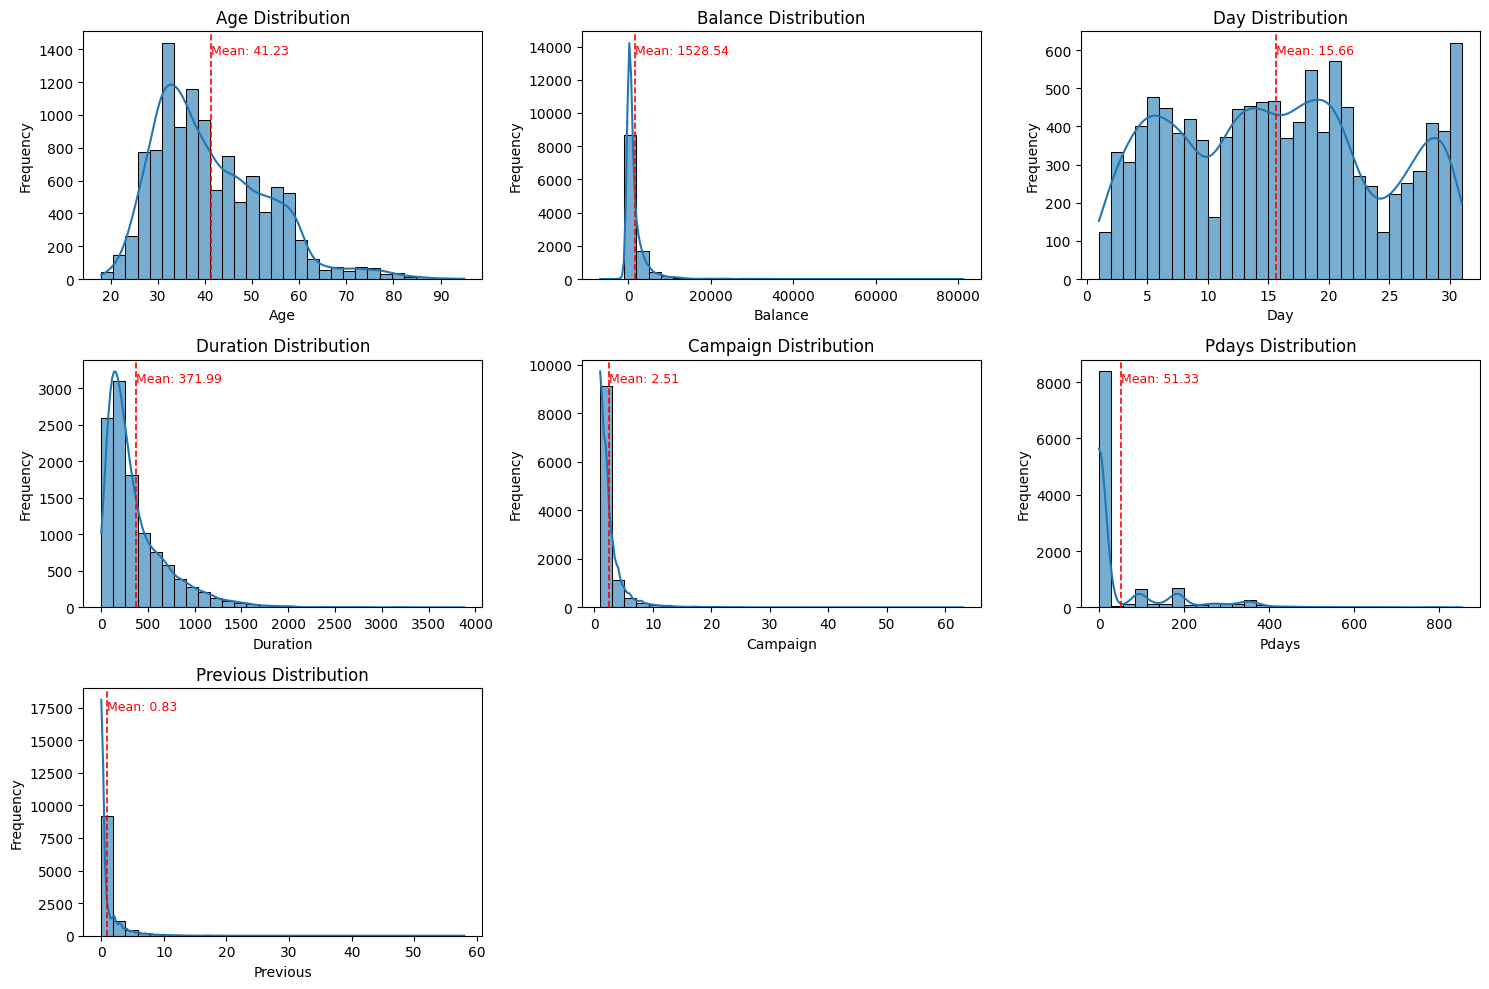

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
present = [c for c in features if c in df.columns]

n = len(present)
rows = int(np.ceil(n / 3))
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, present):
    s = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    mean_val = float(s.mean())

    # histogram + kde
    sns.histplot(s, bins=30, kde=True, ax=ax, edgecolor="black", alpha=0.6)

    # mean line
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.2)
    ax.text(mean_val, ax.get_ylim()[1]*0.95,
            f"Mean: {mean_val:.2f}", color="red", ha="left", va="top", fontsize=9)

    ax.set_title(f"{col.capitalize()} Distribution")
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Frequency")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()




### Analysis:
The histograms with KDE and mean lines revealed the following:

* **Age**: Most customers were between 30 and 50 years old, with the mean age around 41.

* **Balance**: The distribution was highly skewed, with most balances clustered near zero, but some customers holding very high balances (outliers).

* **Duration**: Call duration was also skewed, with most calls being short, but a few lasting very long. Longer calls tended to be associated with higher likelihood of subscription, although this variable is a leakage feature since it’s only known after the call.

* **Campaign & Pdays**: Both distributions were right-skewed, with most customers contacted very few times and long gaps between campaigns.

* **Previous**: Most customers had not been contacted before, but a small number had multiple past contacts.

## 6. Correlation Analysis
A correlation heatmap is produced for numeric variables, including the target.  
This helps in understanding how features are linearly related.

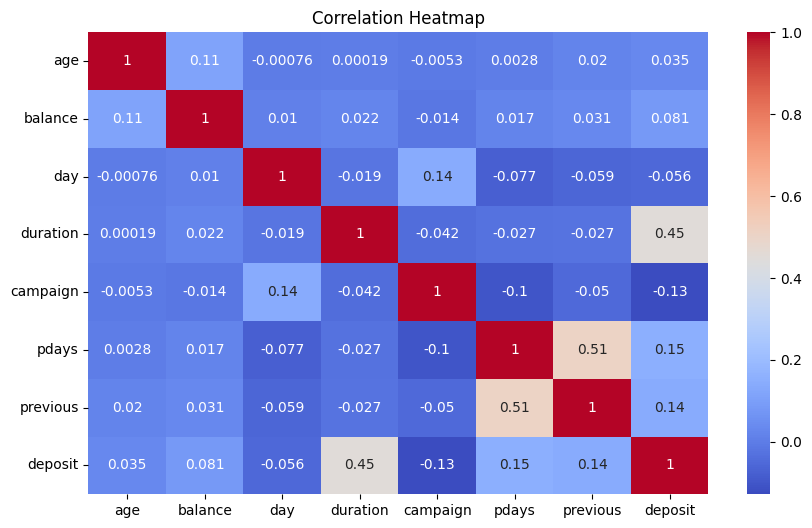

In [5]:
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Analysis:

* **Duration** showed the strongest positive correlation with deposit subscription, reinforcing its predictive but potentially unrealistic role.

* Other numeric features such as pdays and previous had weaker correlations.

* Most numeric variables were not strongly correlated with each other, reducing concerns of multicollinearity.

## 7. Logistic Regression Model
A logistic regression model is trained to predict deposit subscription.  
The dataset is split into training and test sets.  
Numeric features are standardized and categorical features are one-hot encoded.  
Model performance is evaluated using AUC, precision, recall, and confusion matrix.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

X = df.drop(columns=['deposit'])
y = df['deposit']

num = X.select_dtypes(include=np.number).columns.tolist()
cat = [c for c in X.columns if c not in num]

pre = ColumnTransformer([
    ('num', StandardScaler(), num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
])

pipe = Pipeline([
    ('prep', pre),
    ('clf', LogisticRegression(max_iter=300))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
pipe.fit(X_train, y_train)

proba = pipe.predict_proba(X_test)[:,1]
pred = (proba >= 0.5).astype(int)

print("AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))


AUC: 0.907139122390701
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1175
           1       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.83      2233
weighted avg       0.83      0.83      0.83      2233

Confusion Matrix:
 [[999 176]
 [212 846]]


### Analysis:
The logistic regression model performed well, with an AUC of ~0.91. Precision, recall, and F1 scores were balanced between the positive and negative classes, and overall accuracy was ~83%.

The confusion matrix showed that:

* About 999 true negatives and 846 true positives were correctly classified.

* Some false positives (176) and false negatives (212) were still present, indicating room for improvement.

This demonstrates that even a simple linear model can capture meaningful patterns in the dataset. However, reliance on features such as **duration** might overstate performance compared to real-world pre-call predictions.

## 8. Key Findings
- The **overall deposit subscription rate** was relatively low at ~11%, highlighting the challenge of converting customers through marketing calls.

- **Students** and **retired customers** exhibited higher subscription rates compared to other occupations, indicating that demographic segments influence responsiveness.

- **Timing mattered**: the month of March recorded a noticeably higher response rate, suggesting campaign success is partially seasonal.

- **Call duration** showed a strong relationship with positive responses. However, this is a leakage variable, since duration is only known after the call. Using it in real-time predictions would overestimate model performance.

- The **Logistic Regression model** performed reasonably well, achieving an AUC of ~0.91 and balanced precision/recall, showing predictive potential even with a simple linear approach.

## 9. Recommendations
- Focus on students, retirees, and customers with successful past outcomes, who show higher subscription rates.

- Campaigns in March performed better; prioritize mobile/cell contact over landline.

- Limit repeated calls, as too many follow-ups reduce effectiveness and waste resources.

- Use A/B testing for timing and messaging, and tailor incentives to different demographics.